# 01 — A série e as falhas

O ponto de partida do projeto, em duas figuras:

1. **a série** — o que os sensores registraram nos 16 meses publicados no ClearML;
2. **as falhas** — quando a máquina de fato caiu, e em que contexto.

Tudo aqui é dado bruto: nenhum modelo entra neste notebook. Ele existe para que,
ao olhar as figuras de anomalia do notebook 03, dê para comparar o que o modelo
marcou com o que a série realmente mostra.

O formato visual é o dos notebooks do projeto `Transpetro-modelos`
(`notebooks/*/plot_anomalias.ipynb`): série em **azul**, falha real como **linha
vertical laranja tracejada**, e — acréscimo daqui — **cinza de fundo onde a
máquina estava parada**, porque este equipamento passa boa parte do tempo
desligado e sem isso o gráfico engana.

In [1]:
import sys
import warnings
from pathlib import Path

import pandas as pd

warnings.filterwarnings("ignore")
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

from cabiunas_pdm import viz
from cabiunas_pdm.replay import CachedBundle, SENSORS_OVERVIEW, load_alarms, load_automl

viz.usar_estilo()
automl = load_automl()                    # mesma fonte de dados do AutoML

bundle = CachedBundle().build()           # série limpa do dataset do ClearML
sensores, operacao = bundle.grid("2min")  # 30 s reamostrado para 2 min (desenho)
falhas = automl.merge_events(bundle.trips(), automl.EVENT_GAP)   # varredura, não lista fixa
alarmes = load_alarms()

inicio, fim = sensores.index[0], sensores.index[-1]
passo = operacao.index.to_series().diff().dt.total_seconds().median()
dias_operando = operacao["in_operation"].sum() * passo / 86400
no_periodo = alarmes.loc[inicio:fim]
ativados = no_periodo[no_periodo["ativado"]]

pd.Series({
    "período": f"{inicio:%d/%m/%Y} → {fim:%d/%m/%Y}",
    "amostras (30 s)": f"{len(bundle.raw):,}".replace(",", "."),
    "sensores": bundle.raw.shape[1],
    "dias de calendário": round((fim - inicio).total_seconds() / 86400),
    "dias em operação": round(dias_operando),
    "% do tempo operando": f"{dias_operando / ((fim - inicio).total_seconds() / 86400):.0%}",
    "alarmes ativados no período": len(ativados),
    "…de nível (derrubam a máquina)": int(ativados["nivel_trip"].sum()),
    "trips detectados (parada >= 2 h + alarme de nível)": len(bundle.trips()),
    "falhas (trips a menos de 24 h contam como uma)": len(falhas),
    "paradas reais (>= 2 h) no período": len(bundle.stops("2min")),
}).to_frame("valor")

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


,valor
período,01/01/2025 → 30/04/2026
amostras (30 s),1.396.800
sensores,39
dias de calendário,485
dias em operação,370
% do tempo operando,76%
alarmes ativados no período,1096
…de nível (derrubam a máquina),108
trips detectados (parada >= 2 h + alarme de nível),9
falhas (trips a menos de 24 h contam como uma),8


## 1. A série

Cinco sensores, um por assunto: o mancal que mais falha (`TI_0305`), a temperatura
de exaustão da turbina (`T5_AVG_A`), a pressão de óleo (`PI_0315`), o diferencial
de selagem (`PDIT_0305`) e a vibração (`TV_351X_A`).

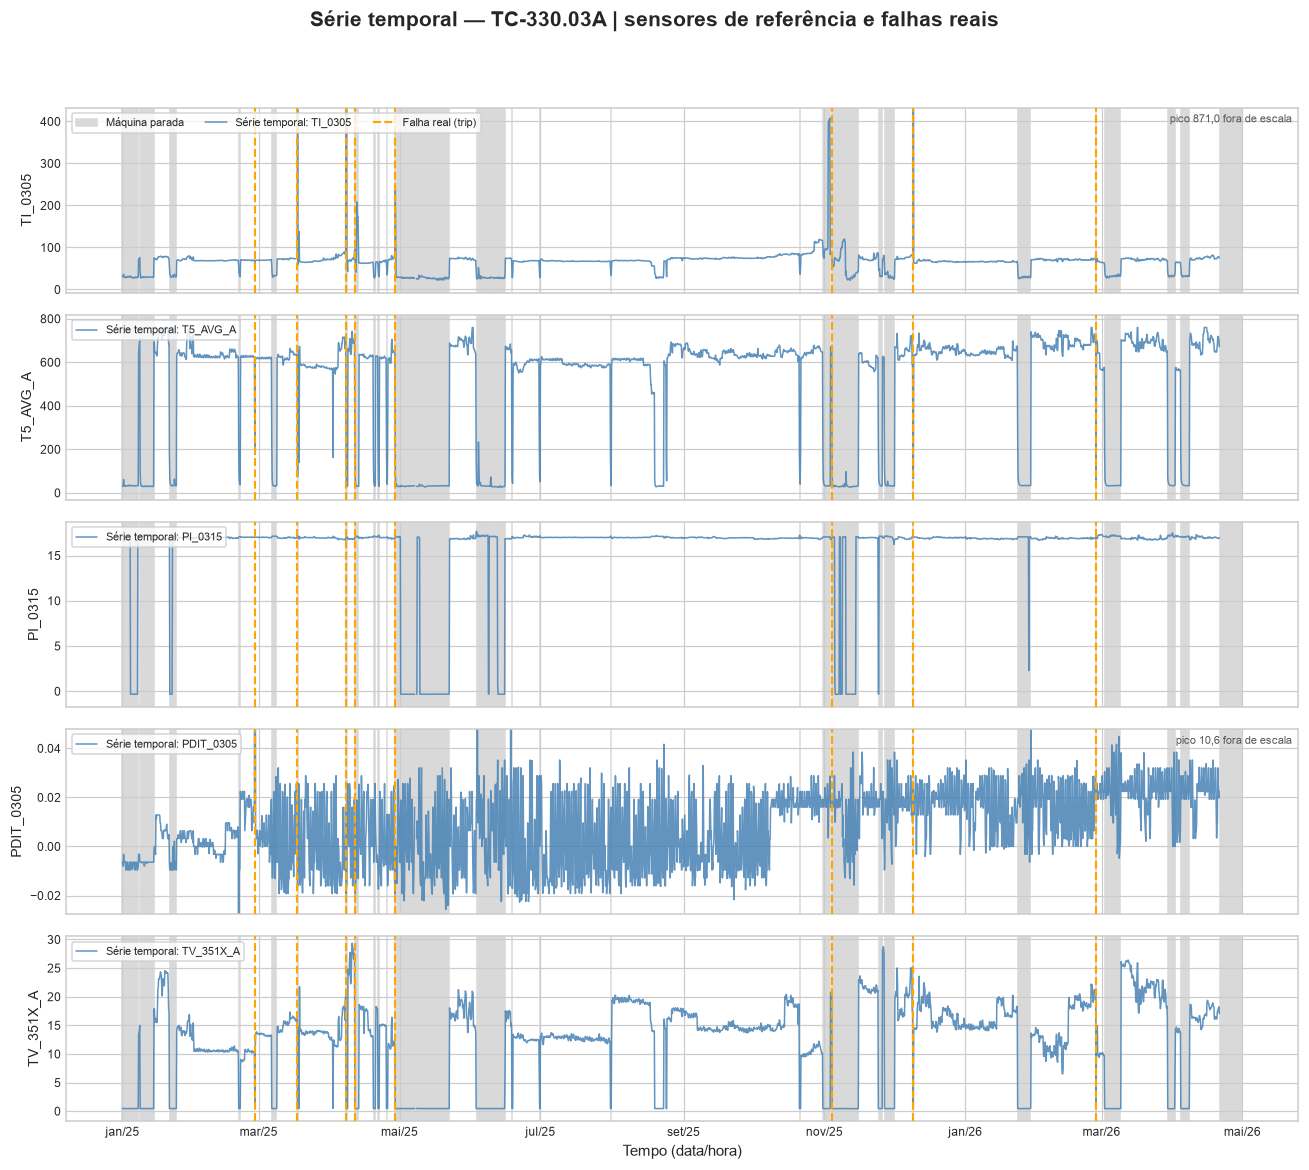

In [2]:
viz.plot_series(sensores, operacao, falhas, SENSORS_OVERVIEW);

### O que a figura já mostra

* **A máquina liga e desliga o tempo todo.** As faixas cinza são paradas, e é por
  isso que "dias de calendário" e "dias de exposição" são coisas diferentes aqui.
  Todo o resto do projeto conta apenas o tempo em operação.
* **Cada sensor tem dois patamares**: um de operação e outro de máquina parada
  (`T5_AVG_A` cai de ~650 °C para ~30 °C, `TV_351X_A` vai a zero). Sem separar os
  dois, qualquer modelo aprende "ligado × desligado" em vez de "saudável × doente".
* **`TI_0305` salta para 871 °C no instante do trip** (anotado como fora de
  escala). É leitura de termopar em falha, não temperatura real de mancal — motivo
  pelo qual a limpeza corta valores fora da faixa física.
* **A vibração sobe ao longo dos meses** (de ~10 para ~25 entre jan/25 e mar/26)
  sem que nada tenha quebrado por vibração. É essa deriva que a mantém em
  quarentena como sinal de alarme: ela geraria falso positivo crescente.
* **`PDIT_0305` muda de caráter em mar/2025**: a amplitude do ruído multiplica.
  É o sinal da selagem — o mecanismo que o detector menos enxerga hoje.

## 2. As falhas no decorrer do tempo

Três faixas no mesmo eixo de tempo:

1. **horas operadas por dia** — o ritmo de operação e as paradas;
2. **alarmes ativados por dia** (escala log), com os de **nível** — os que derrubam
   a máquina — em vermelho;
3. **a linha do tempo das falhas**, uma faixa por mecanismo.

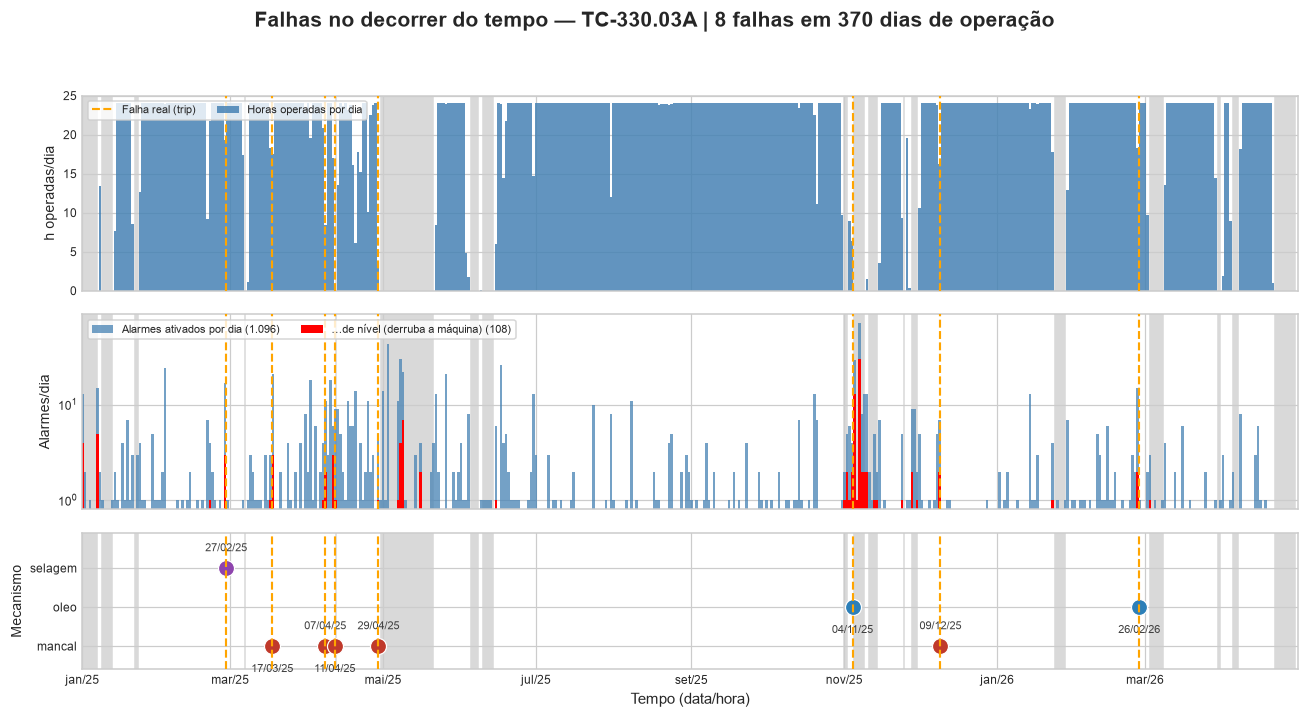

In [3]:
viz.plot_falhas(falhas, operacao, alarmes);

In [4]:
operando = operacao["in_operation"]

def horas_antes(quando, janela="48h"):
    trecho = operando.loc[quando - pd.Timedelta(janela):quando]
    return round(float(trecho.sum()) * passo / 3600, 1)

tabela = pd.DataFrame([{
    "falha": e["inicio"],
    "mecanismo": e["mecanismo"],
    "trips": len(e["trips"]),
    "operou_nas_48h": horas_antes(e["inicio"]),
} for e in falhas])
tabela["dias_desde_a_anterior"] = tabela["falha"].diff().dt.total_seconds() / 86400
tabela.round(1)

,falha,mecanismo,trips,operou_nas_48h,dias_desde_a_anterior
0,2025-02-27 08:38:00,selagem,1,48.0,NaN
1,2025-03-17 18:16:00,mancal,2,48.0,18.4
2,2025-04-07 21:18:00,mancal,1,47.6,21.1
3,2025-04-11 17:04:00,mancal,1,48.0,3.8
4,2025-04-29 03:04:00,mancal,1,47.8,17.4
5,2025-11-04 06:22:00,oleo,1,15.3,189.1
6,2025-12-09 08:36:00,mancal,1,47.8,35.1
7,2026-02-26 15:34:00,oleo,1,48.0,79.3


### O que a figura já mostra

* **Oito falhas em ~370 dias de operação.** É pouco para qualquer modelo
  supervisionado: oito exemplos positivos, de três mecanismos diferentes
  (mancal, óleo, selagem), não dão para treinar um classificador de falha. Daí a
  escolha por detecção de anomalia — modelar o *normal*, que é abundante.
* **As falhas se concentram em fev–abr/2025.** Cinco das oito acontecem em três
  meses; depois vêm seis meses sem nenhuma. Qualquer avaliação que não seja
  temporal (walk-forward) se ilude com isso.
* **O alarme não serve de rótulo.** Repare no pico vermelho de 04/11/2025: dezenas
  de alarmes de nível no mesmo dia — a esmagadora maioria disparando com a máquina
  **já parada**, como consequência da parada e não como aviso. A conta está na
  célula abaixo.

In [5]:
# "de nível" = descrição casa com TRIP|Mt.Alta|M.Alta|Mt.Bx|M.Bx|Mt.Baixa|M.Baixa.
# Esse padrão foi validado contra a tag real (TAHH_/PALL_/PDAHH, que só existe na
# outra versão do dataset) nas 6.851 linhas da planilha: 100% de concordância.
nivel = ativados[ativados["nivel_trip"]]
com_maquina_parada = sum(1 for t in nivel.index if not bool(operando.asof(t)))
print(f"alarmes de nível no período: {len(nivel)}")
print(f"disparados com a máquina JÁ PARADA: {com_maquina_parada} "
      f"({com_maquina_parada / len(nivel):.0%})")
print("→ por isso o alarme de nível não é usado como rótulo de falha, e sim a "
      "lista de trips catalogados")

alarmes de nível no período: 108
disparados com a máquina JÁ PARADA: 102 (94%)
→ por isso o alarme de nível não é usado como rótulo de falha, e sim a lista de trips catalogados


## 3. Falha ou alarme? — o que exatamente estamos chamando de falha

Vale parar nisso, porque a nomenclatura confunde e o projeto inteiro depende dela.

**Não existe registro de manutenção neste conjunto de dados.** Não há ordem de
serviço, laudo, nem causa raiz confirmada por quem foi ao campo. O que existe é:

* a **planilha de alarmes** (o que a instrumentação registrou), e
* a **série dos sensores**, que inclui `RUNNING_A` — o estado da máquina.

Então "falha" aqui é um rótulo **derivado**, com uma definição precisa:

> **parada real** = `RUNNING_A` 1→0 que dura **≥ 2 h** (abaixo disso é queda de
> telemetria: 97 das 135 transições na grade de 30 s duram menos de 3 min).
> **trip** = parada real que coincide com **alarme de nível** na janela
> [−1 h, +30 min]. **falha (evento)** = trips a menos de 24 h, contados como um.
>
> A lista **não é digitada à mão** — sai dessa varredura. A versão anterior era
> fixa no código e perdia duas falhas, inclusive a de 29/04/2025, que tirou a
> máquina de operação por 23 dias.

A figura abaixo é a prova disso, trip a trip: a faixa azul é a máquina operando, a
linha laranja é o alarme de nível, e o que se vê é a faixa azul terminando
exatamente na linha.

In [6]:
# a mesma verificação em números, na grade fina de 30 s
from cabiunas_pdm.replay import duracao_da_parada

_, operacao_fina = bundle.grid("30s")
fina = operacao_fina["in_operation"]

def verificar(quando):
    t = pd.Timestamp(quando)
    parada = duracao_da_parada(operacao_fina, t)
    return {
        "operando_antes": f"{fina.loc[t - pd.Timedelta('30min'):t].mean():.0%}",
        "parou_depois": parada["parou"],
        "parada_h": parada["horas"],
    }

pd.DataFrame([{"trip": pd.Timestamp(q), "mecanismo": m, **verificar(q)}
              for q, m in bundle.trips()])

,trip,mecanismo,operando_antes,parou_depois,parada_h
0,2025-02-27 08:38:00,selagem,98%,True,4.4
1,2025-03-17 18:16:00,mancal,97%,True,6.2
2,2025-03-18 11:16:00,mancal,100%,True,4.0
3,2025-04-07 21:18:00,mancal,98%,True,18.3
4,2025-04-11 17:04:00,mancal,95%,True,41.4
5,2025-04-29 03:04:00,mancal,97%,True,564.2
6,2025-11-04 06:22:00,oleo,100%,True,129.9
7,2025-12-09 08:36:00,mancal,98%,True,7.8
8,2026-02-26 15:34:00,oleo,98%,True,5.7


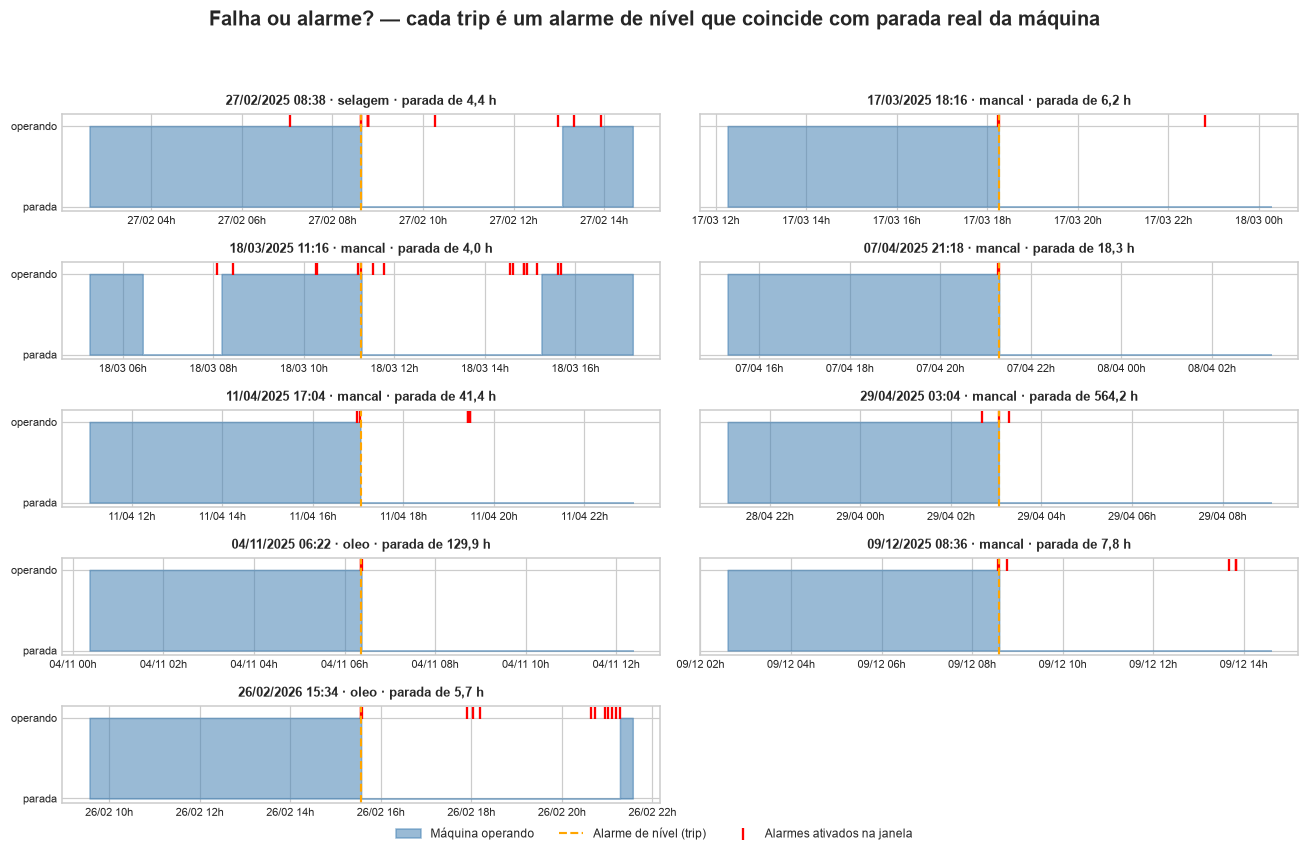

In [7]:
viz.plot_evidencia_falhas(operacao_fina, bundle.trips(), alarmes);

### O que a verificação mostra

**Os nove trips são inequívocos**: a máquina estava operando nos 30 min
anteriores, parou no instante do alarme e ficou parada de **4 h a 564 h**. Isso é
parada real de equipamento, não ruído de instrumentação.

O critério de 2 h já descarta o caso duvidoso: em 27/02/2025 17:33 houve alarme de
selagem com apenas 12 min de interrupção. Ele fica de fora da lista — e não muda
nada, porque está a menos de 24 h do trip das 08:38 e já contava como o mesmo
evento físico.

### Vocabulário do projeto

| Termo | O que é | Quantos no período |
|---|---|---|
| **alarme** | uma linha da planilha da instrumentação; a maioria é aviso | 1.096 ativações |
| **alarme de nível** | o subconjunto que derruba a máquina (`LL`/`HH`/TRIP) | 83 |
| **parada real** | `RUNNING_A` 1→0 durando ≥ 2 h | 36 |
| **trip** | parada real **+** alarme de nível junto | 9 |
| **falha (evento)** | trips a menos de 24 h agrupados | 8 |

O que **não** temos, e que mudaria o projeto se tivéssemos: a confirmação de campo
do que quebrou. O "mecanismo" (óleo / mancal / selagem) vem da tag do alarme que
disparou — é uma inferência razoável, não um diagnóstico.

## O que isso decide sobre a modelagem

| Fato desta base | Consequência |
|---|---|
| 6 falhas, 3 mecanismos | supervisionado inviável → **detecção de anomalia** (modelar o normal) |
| máquina parada boa parte do tempo | tudo é calculado **só sobre o tempo em operação**, com 2 h de exclusão após cada partida |
| falhas agrupadas em fev–abr/2025 | validação **temporal** (walk-forward, re-baseline mensal), nunca aleatória |
| 94% dos alarmes de nível dispararam com a máquina já parada | alarme é **consequência**, não rótulo — o evento exige parada real junto |
| não há registro de manutenção | "falha" é rótulo derivado (alarme de nível + parada real), e o mecanismo vem da tag do alarme |
| vibração deriva entre meses sem falha associada | vibração fica em **quarentena** como sinal de alarme |

Os dois notebooks seguintes partem daqui: **02** mede a fronteira
detecção × falso positivo de milhares de configurações, e **03** mostra as
anomalias do detector escolhido sobre esta mesma série.